In [5]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable


In [6]:
import shap
print(shap.__version__)

0.52.0


In [7]:
import warnings
warnings.filterwarnings("ignore")
import os
import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor

In [17]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme( style="whitegrid", palette="Set2" )
plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["figure.dpi"] = 120

In [18]:
df = pd.read_csv(
"../data/final/ml_dataset.csv"
)

In [19]:
df.columns = (
df.columns
.str.strip()
.str.lower()
)

In [20]:
df["date"] = pd.to_datetime( df["date"] )
df = df.sort_values("date")

In [21]:
TARGET = "log_cases"

In [22]:
REMOVE_COLS = [
"cases",
"log_cases",
"outbreak",
"date",
"id"
]

In [23]:
#FEATURE LIST
FEATURES = [
col
for col in df.columns
if col not in REMOVE_COLS
]

FEATURES = [
col
for col in FEATURES
if pd.api.types.is_numeric_dtype(df[col])
]

print("TOTAL FEATURES")
print(len(FEATURES))

TOTAL FEATURES
29


In [24]:
#FEATURE MATRIX
X = df[FEATURES]
X = X.replace( [np.inf, -np.inf], np.nan )
X = X.fillna(0)
y = df[TARGET]
print(X.shape)

(8984, 29)


In [25]:
model = joblib.load("../artifacts/xgb_regressor.pkl")
print(" Trained Model Loaded")

 Trained Model Loaded


In [26]:
#SAMPLE DATA FOR SHAP
sample_size = min(1000, len(X))
X_sample = X.sample( sample_size, random_state=RANDOM_STATE )
print(f"Sample Size Used: {len(X_sample)}")

Sample Size Used: 1000


In [27]:
#SHAP EXPLAINER
explainer = shap.TreeExplainer( model )
shap_values = explainer.shap_values( X_sample )
print("SHAP Values Generated")

SHAP Values Generated


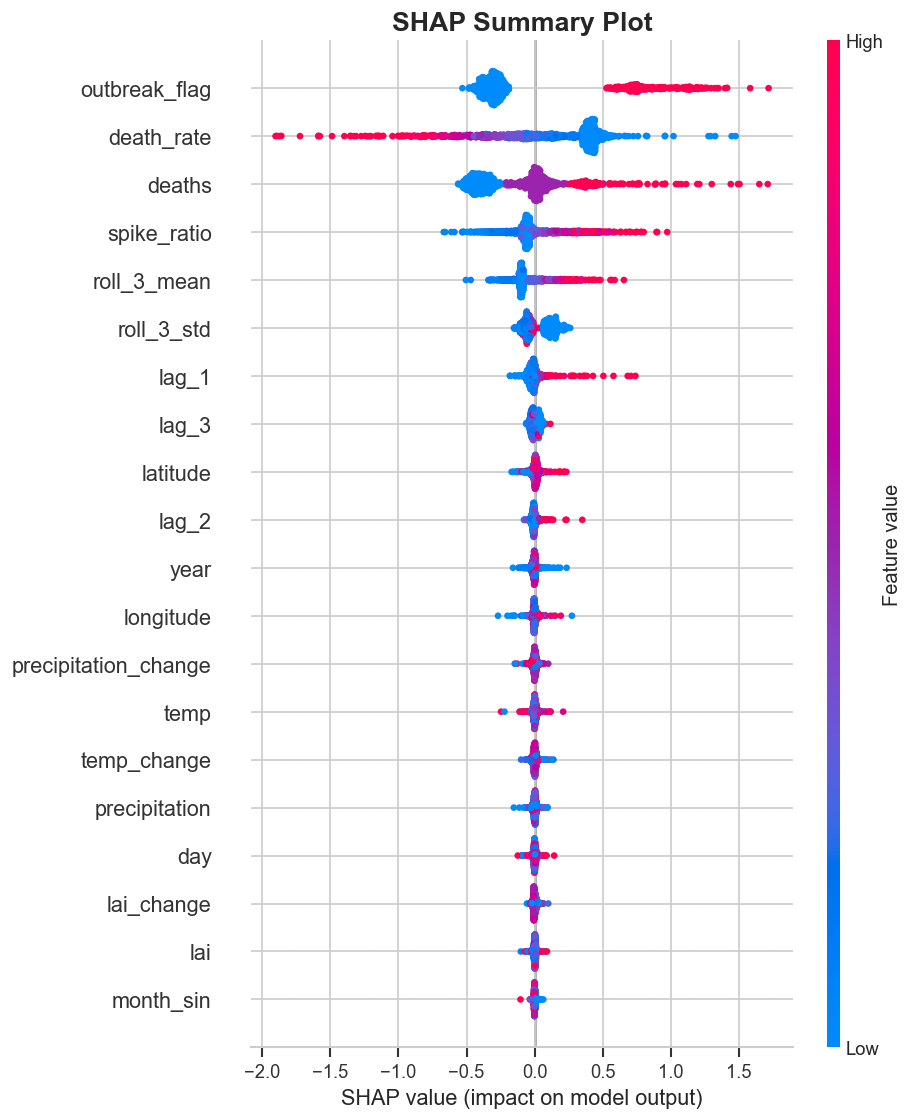

In [28]:
#SHAP SUMMARY PLOT
shap.summary_plot( shap_values, X_sample, show=False )
plt.title( "SHAP Summary Plot", fontsize=16, fontweight="bold" )
plt.tight_layout()
plt.savefig( "../reports/shap_summary_plot.png", bbox_inches="tight" )
plt.show()

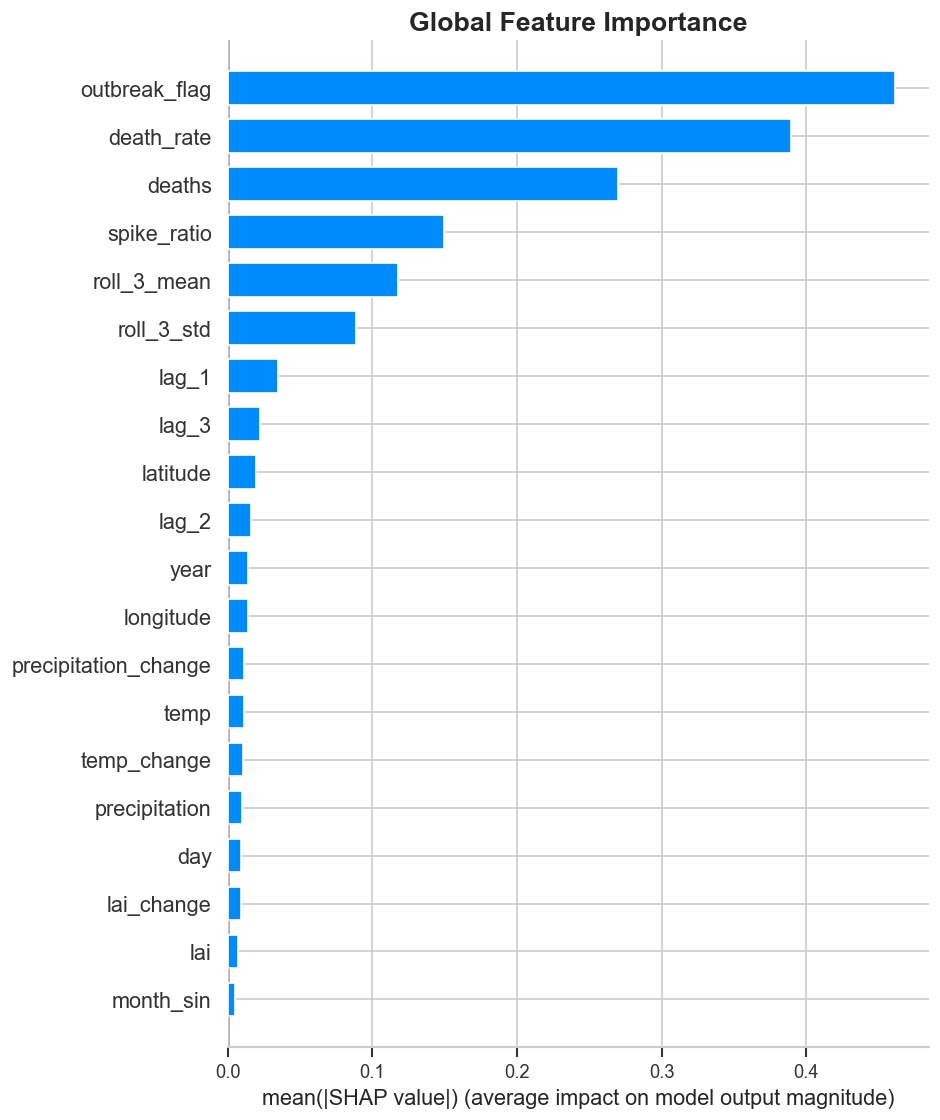

In [29]:
#SHAP BAR PLOT
shap.summary_plot(shap_values,X_sample,plot_type="bar",show=False)
plt.title("Global Feature Importance",fontsize=16,fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/shap_bar_plot.png",bbox_inches="tight")
plt.show()

In [30]:
#MEAN ABSOLUTE SHAP VALUES

shap_importance = pd.DataFrame({
"feature": FEATURES,
"mean_abs_shap": np.abs(
    shap_values
).mean(axis=0)})
shap_importance = (shap_importance.sort_values(by="mean_abs_shap",ascending=False))
print(shap_importance.head(15))

                 feature  mean_abs_shap
27         outbreak_flag       0.461549
9             death_rate       0.389219
0                 deaths       0.270070
24           spike_ratio       0.149662
15           roll_3_mean       0.118083
17            roll_3_std       0.088700
10                 lag_1       0.035091
12                 lag_3       0.022178
4               latitude       0.019760
11                 lag_2       0.016171
3                   year       0.013994
5              longitude       0.013783
22  precipitation_change       0.011455
8                   temp       0.011241
21           temp_change       0.010671


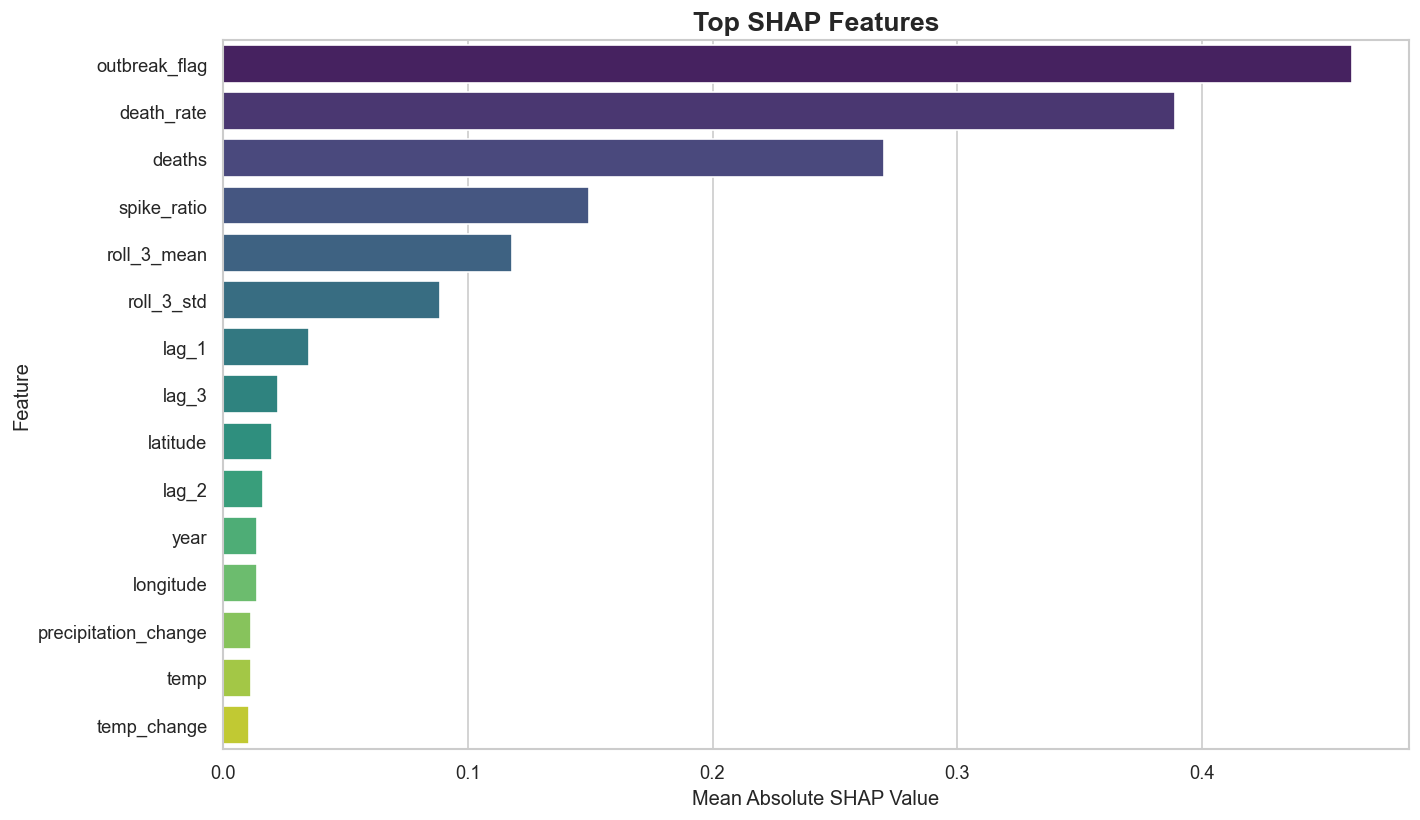

In [31]:
#TOP FEATURES PLOT

top_features = (shap_importance.head(15))
plt.figure(figsize=(12,7))
sns.barplot(data=top_features,x="mean_abs_shap",y="feature",palette="viridis")

plt.title("Top SHAP Features",fontsize=16,fontweight="bold")

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../reports/top_shap_features.png",bbox_inches="tight")
plt.show()

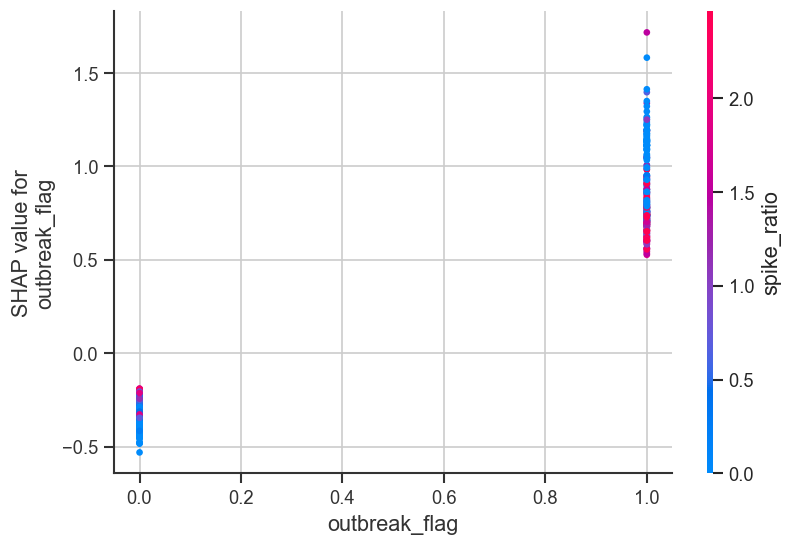

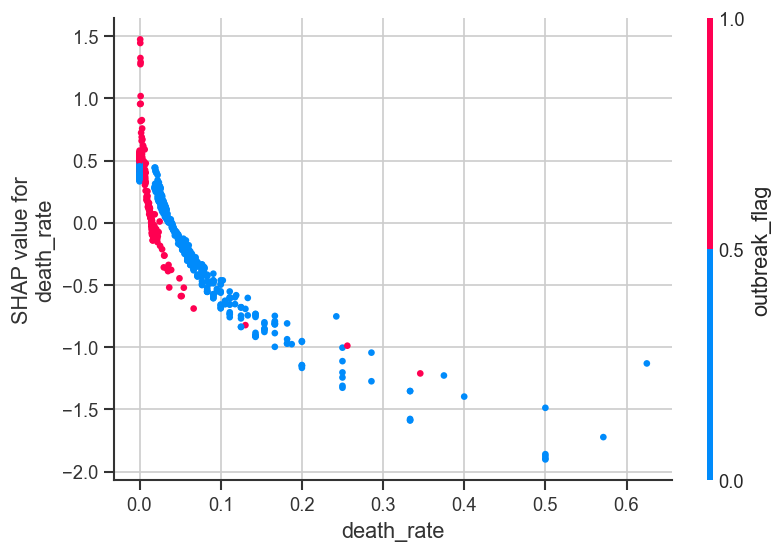

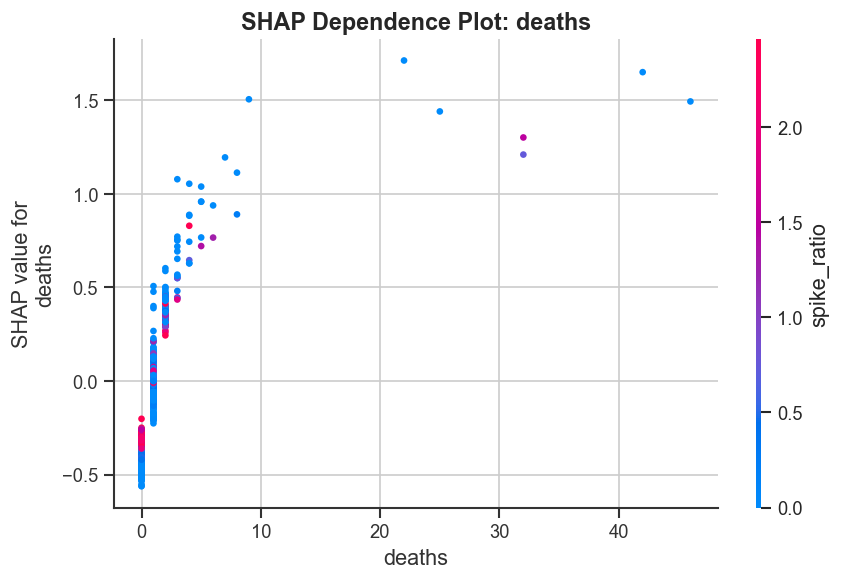

In [33]:
#DEPENDENCE PLOTS

top_3_features = (shap_importance["feature"].head(3).tolist())
for feature in top_3_features:
  shap.dependence_plot(
    feature,
    shap_values,
    X_sample,
    show=False
)
plt.title(
    f"SHAP Dependence Plot: {feature}",
    fontsize=14,
    fontweight="bold"
)
plt.tight_layout()
plt.savefig(
    f"../reports/shap_dependence_{feature}.png",
    bbox_inches="tight"
)
plt.show()

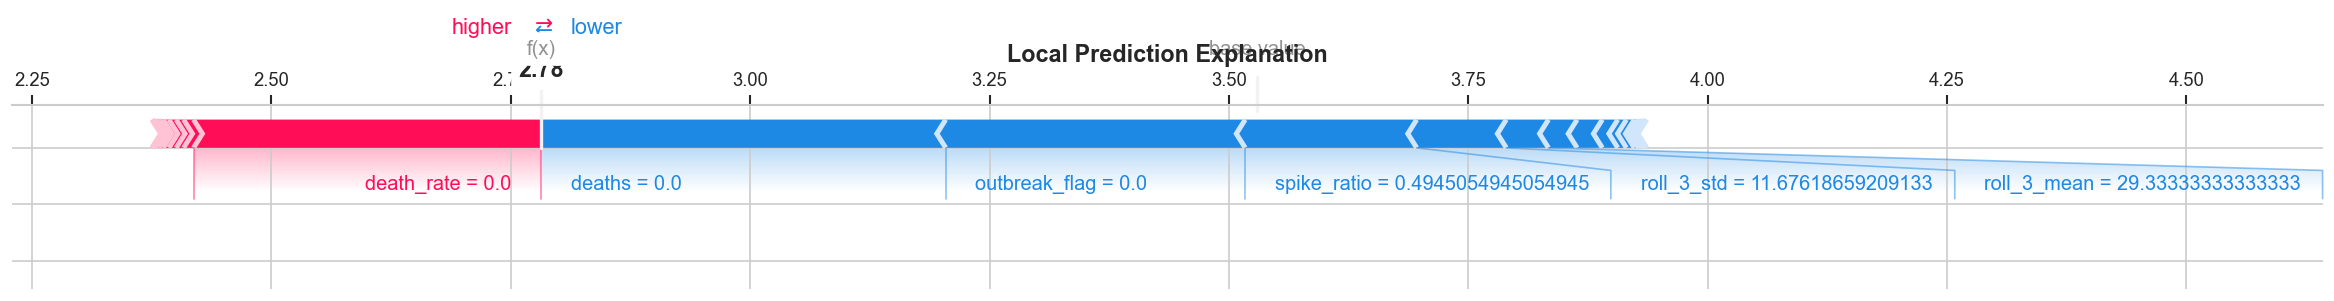

In [34]:
#LOCAL EXPLANATION
sample_index = 0
shap.force_plot(
explainer.expected_value,
shap_values[sample_index],
X_sample.iloc[sample_index],
matplotlib=True,
show=False
)
plt.title("Local Prediction Explanation",fontsize=14,fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/shap_force_plot.png",bbox_inches="tight")
plt.show()

In [35]:
#SAVE SHAP IMPORTANCE
shap_importance.to_csv("../reports/shap_feature_importance.csv",index=False)
print("SHAP Feature Importance Saved")

SHAP Feature Importance Saved


In [36]:
#SAVE EXPERIMENT
os.makedirs("../experiments/exp_04_shap",exist_ok=True)
shap_importance.to_csv("../experiments/exp_04_shap/shap_importance.csv",index=False)
print(" SHAP Experiment Saved")

 SHAP Experiment Saved


In [38]:
#INTERPRETATION SUMMARY
top_5 = (shap_importance["feature"].head(5).tolist())
print("TOP OUTBREAK DRIVERS")
for idx, feature in enumerate(top_5, start=1):
    print(f"{idx}. {feature}")

TOP OUTBREAK DRIVERS
1. outbreak_flag
2. death_rate
3. deaths
4. spike_ratio
5. roll_3_mean


In [41]:
# CREATE SHAP REPORT
with open(
    "../reports/shap_report.md",
    "w",
    encoding="utf-8"
) as f:
    f.write("# SHAP Explainability Report\n\n")
    f.write("## Top Influential Features\n\n")
    for idx, feature in enumerate(top_5, start=1):
        f.write(f"{idx}. {feature}\n")
    f.write("\n")
    f.write(
        "These variables showed the strongest contribution "
        "towards outbreak prediction and case forecasting."
    )
print("SHAP Report Saved")

SHAP Report Saved


In [43]:
#FINAL SUMMARY
summary_df = pd.DataFrame({
"Metric": [
    "Total Features",
    "Sample Size",
    "Top Feature"
],
"Value": [
    len(FEATURES),
    len(X_sample),
    top_5[0]
]})
summary_df.style.background_gradient(cmap="Blues").hide(axis="index")

Metric,Value
Total Features,29
Sample Size,1000
Top Feature,outbreak_flag
